In [33]:
# Cell 1: Install & imports & config (GPU + 4-bit)
%pip install -q "transformers>=4.46.0" "peft>=0.11.0" "qwen-vl-utils" "accelerate>=1.0.0" "bitsandbytes>=0.43.0"

import gc
from pathlib import Path

import torch
from peft import LoraConfig, get_peft_model
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from PIL import Image

# === ĐƯỜNG DẪN MODEL LOCAL ===
MODEL_PATH = "/kaggle/input/final-data/base_model/base_model"  # thư mục chứa config.json, model.safetensors...

SFT_CKPT   = Path("/kaggle/input/final-data/qwen2vl_sft_stage0_best.pt")
RL_CKPT    = Path("/kaggle/input/final-data/qwen2vl_rl_stage1_best_V4_1100.pt")
TEST_IMAGE = "/kaggle/input/final-data/test3.jpg"

PROMPT = "Describe the image in a detailed, accurate English caption."

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Model path exists:", Path(MODEL_PATH).exists())
print("SFT ckpt exists:", SFT_CKPT.exists())
print("RL  ckpt exists:", RL_CKPT.exists())

# Processor cũng load từ local model, không cần internet
processor = AutoProcessor.from_pretrained(
    MODEL_PATH,
    min_pixels=256 * 256,
    max_pixels=640 * 640,
    local_files_only=True,
)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.
Device: cuda
Model path exists: True
SFT ckpt exists: True
RL  ckpt exists: True


In [8]:
# Cell 2: Hàm caption với config + seed
from IPython.display import display

@torch.no_grad()
def caption_image(
    model,
    image_path: str,
    max_new_tokens: int = 200,
    min_new_tokens: int = 32,
    do_sample: bool = True,
    temperature: float = 0.7,
    top_p: float = 0.9,
    top_k: int = 50,
    seed: int | None = None,
):
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    image = Image.open(image_path).convert("RGB")
    image.thumbnail((512, 512))

    # hiện ảnh để bạn nhìn
    display(image)

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": PROMPT},
        ],
    }]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt",
        padding=True,
    ).to(device)

    gen_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        min_new_tokens=min_new_tokens,
        do_sample=do_sample,
        temperature=temperature,
        top_p=top_p,
        top_k=top_k,
        repetition_penalty=1.05,
    )

    input_len = inputs["input_ids"].shape[1]
    new_ids = gen_ids[:, input_len:]

    caption = processor.batch_decode(
        new_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    print(f"(tokens: {new_ids.shape[1]}, chars: {len(caption)})")
    print(caption)
    return caption


In [26]:
# Cell 3: Hàm load base sạch & load model + LoRA

def load_base_model_clean():
    """Load base Qwen2-VL-2B-Instruct 4-bit, KHÔNG LoRA."""
    gc.collect()
    torch.cuda.empty_cache()

    model = Qwen2VLForConditionalGeneration.from_pretrained(
        MODEL_PATH,
        quantization_config=bnb_config,
        device_map=device,
        local_files_only=True,
    )
    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    print("Loaded CLEAN base model (no LoRA).")
    print("First param device:", next(model.parameters()).device)
    return model


def load_lora_model_from_ckpt(ckpt_path: Path):
    """Load base 4-bit + gắn LoRA rồi nạp trọng số LoRA từ ckpt."""
    gc.collect()
    torch.cuda.empty_cache()

    base_model = Qwen2VLForConditionalGeneration.from_pretrained(
        MODEL_PATH,
        quantization_config=bnb_config,
        device_map=device,
        local_files_only=True,
    )
    base_model.eval()
    for p in base_model.parameters():
        p.requires_grad = False

    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=[
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj",
        ],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )

    model = get_peft_model(base_model, lora_config)
    model.eval()

    state = torch.load(ckpt_path, map_location="cpu")
    lora_state = {k: v for k, v in state.items() if "lora" in k.lower()}
    del state
    missing, unexpected = model.load_state_dict(lora_state, strict=False)

    print(f"Loaded LoRA from {ckpt_path}")
    print("  LoRA keys:", len(lora_state), "| missing:", len(missing), "| unexpected:", len(unexpected))
    print("First param device:", next(model.parameters()).device)

    gc.collect()
    torch.cuda.empty_cache()
    return model



================ BASE: Qwen2-VL ===============


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded CLEAN base model (no LoRA).
First param device: cuda:0


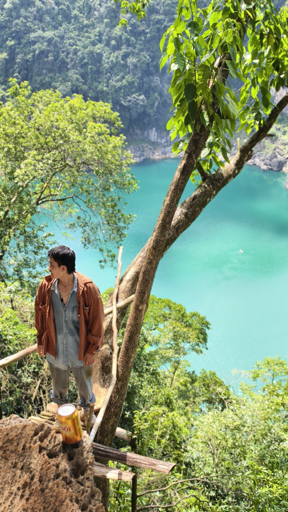

(tokens: 41, chars: 141)
Trong ảnh, một người đàn ông đứng trên cung cấp, nhìn ra vào phía trước. Bằng lưng là một hồ nước xanh ngọc và những cây xanh trong khu rừng.

================ STAGE0: SFT ==================


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded LoRA from /kaggle/input/final-data/qwen2vl_sft_stage0_best.pt
  LoRA keys: 392 | missing: 730 | unexpected: 0
First param device: cuda:0


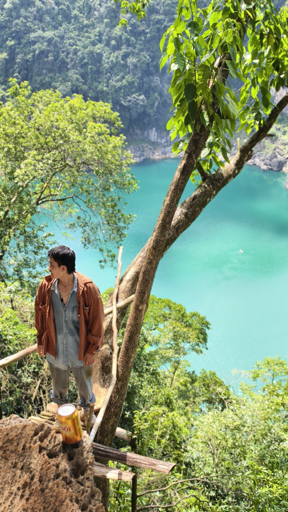

(tokens: 143, chars: 679)
In the heart of the image, a person stands on a rocky ledge, their figure small against the vast expanse of nature. The person is dressed in a vibrant red jacket and blue jeans, adding a splash of color to the scene. The ledge they stand on is nestled amidst a lush forest. Trees and bushes blanket the landscape, their green hues contrasting with the clear blue waters of a lake that lies beyond. The lake is a mirror of the sky above, its surface shimmering under the sunlight. The person's gaze is directed towards the lake, their attention drawn by the serene beauty of the scene. The overall scene is one of tranquility and beauty, a snapshot of nature at its most peaceful.

================ STAGE1: RL ===================


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded LoRA from /kaggle/input/final-data/qwen2vl_rl_stage1_best_V4_1100.pt
  LoRA keys: 392 | missing: 730 | unexpected: 0
First param device: cuda:0


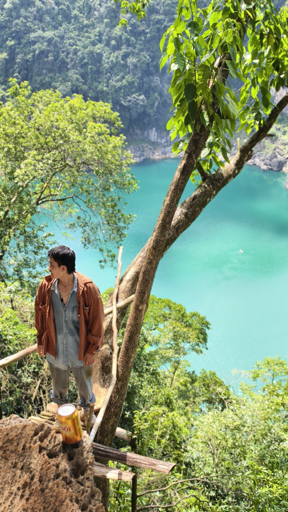

(tokens: 138, chars: 490)
Trong bức ảnh này, một người đàn ông đang đứng trên một đồi ở chân hồ nước xanh mát. Anh ấy đang nhìn ra phía trước với vẻ bình tĩnh và tự tin. Trên lưng anh ấy là một chiếc áo khoác màu đỏ, tạo nên sự nổi bật đối với thiên nhiên xung quanh. Hồ nước trong bức ảnh có màu xanh đậm, làm cho nó trở nên nổi bật và thu hút sự chú ý. Hồ nước nằm ở giữa những cây cỏ và rừng cây, tạo nên một cảnh quan tuyệt vời. Mặt trời đang chiếu sáng lên trời, khiến cho ánh nắng ban đêm trở nên dịu dàng hơn.


In [27]:
# Cell 4: So sánh Base vs SFT vs RL trên cùng 1 ảnh
def compare_three(image_path: str, seed: int | None = 42):
    # 1) BASE: Qwen2-VL sạch
    print("\n================ BASE: Qwen2-VL ===============")
    base_model = load_base_model_clean()
    cap_base = caption_image(
        base_model,
        image_path,
        max_new_tokens=150,
        min_new_tokens=40,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        top_k=50,
        seed=seed,
    )
    del base_model
    gc.collect()
    torch.cuda.empty_cache()

    # 2) STAGE0: SFT
    print("\n================ STAGE0: SFT ==================")
    sft_model = load_lora_model_from_ckpt(SFT_CKPT)
    cap_sft = caption_image(
        sft_model,
        image_path,
        max_new_tokens=250,
        min_new_tokens=40,
        do_sample=True,
        temperature=0.6,   # factual hơn
        top_p=0.9,
        top_k=50,
        seed=seed,
    )
    del sft_model
    gc.collect()
    torch.cuda.empty_cache()

    # 3) STAGE1: RL
    print("\n================ STAGE1: RL ===================")
    rl_model = load_lora_model_from_ckpt(RL_CKPT)
    cap_rl = caption_image(
        rl_model,
        image_path,
        max_new_tokens=150,
        min_new_tokens=40,
        do_sample=True,
        temperature=0.65,   # cho RL "bay" hơn chút
        top_p=0.9,
        top_k=50,
        seed=seed,
    )
    del rl_model
    gc.collect()
    torch.cuda.empty_cache()

    return cap_base, cap_sft, cap_rl

# GỌI THỬ:
caps = compare_three(TEST_IMAGE, seed=42)



================ STAGE1: RL ===================


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded LoRA from /kaggle/input/final-data/qwen2vl_rl_stage1_best_V4_1100.pt
  LoRA keys: 392 | missing: 730 | unexpected: 0
First param device: cuda:0


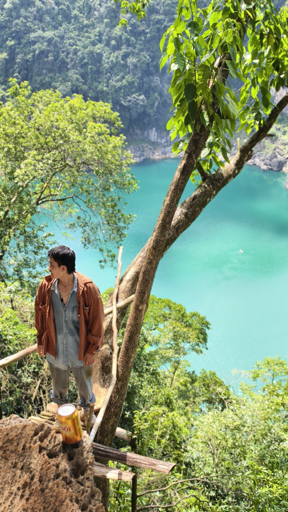

(tokens: 137, chars: 482)
Trong bức ảnh này, một người đàn ông đang đứng trên một đồi ở chân hồ nước xanh mát. Anh đang nhìn ra hồ từ vị trí cao nhất của đồi. Hồ nước xanh tươi và thơ mộng nằm ở bên phải của bức ảnh. Mặt trời đã lên nên ánh nắng chiếu đến mặt hồ, khiến cho không khí trở nên mát mẻ hơn. Trên đỉnh đồi, có một cây cổ thụ lớn với những tán lá rộng lớn. Mặt tiền của cây là một chiếc đĩa màu vàng bắt mắt. Tất cả các chi tiết trong bức ảnh đều phản ánh sự yên bình và tĩnh lặng của thiên nhiên.


In [32]:
# Cell 4: So sánh Base vs SFT vs RL trên cùng 1 ảnh
def compare_three(image_path: str, seed: int | None = 42):

    # 3) STAGE1: RL
    print("\n================ STAGE1: RL ===================")
    rl_model = load_lora_model_from_ckpt(RL_CKPT)
    cap_rl = caption_image(
        rl_model,
        image_path,
        max_new_tokens=250,
        min_new_tokens=40,
        do_sample=True,
        temperature=0.7,   # cho RL "bay" hơn chút
        top_p=0.8,
        top_k=1000,
        seed=seed,
    )
    del rl_model
    gc.collect()
    torch.cuda.empty_cache()

    return cap_rl

# GỌI THỬ:
caps = compare_three(TEST_IMAGE, seed=42)
